# 1. 환경설정 및 데이터 로드

In [1]:
!pip install pytorch-tcn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
from numpy.typing import ArrayLike
from pytorch_tcn.tcn import TCN
from pytorch_tcn.conv import TemporalConv1d
from pytorch_tcn.conv import TemporalConvTranspose1d
from sklearn.metrics import precision_recall_fscore_support

In [3]:
#일부 전처리 된 네트워크 flow 데이터 불러오기
data = pd.read_csv('pre_NF_data.csv',index_col=0)
data.head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,-1.322581,2,...,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,0.845318,28,...,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,1.512126,238,...,0,1843,10,119,0,1843,5,88,0,Benign
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,-1.322581,2,...,0,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,-1.394659,2,...,0,0,0,0,0,0,0,0,0,Benign


# 2. 데이터 전처리 및 분할

### 2-1. 데이터 전처리(세션별 레코드 그룹화)

In [4]:
#동일한 세션에 속한 레코드 그룹화
label=['IPV4_SRC_ADDR','L4_SRC_PORT','IPV4_DST_ADDR','L4_DST_PORT','PROTOCOL']
grouped = data.groupby(label)

In [5]:
#각 세션의 key(src_ip, src_port, dst_ip, dst_port, protocol)
grouped_keys = list(grouped.groups.keys())
grouped_keys[:10]

[('10.40.182.1', 0, '224.0.0.5', 0, 89),
 ('10.40.182.1', 33265, '10.40.198.10', 53, 17),
 ('10.40.182.1', 36101, '10.40.198.10', 53, 17),
 ('10.40.182.1', 54977, '10.40.198.10', 53, 17),
 ('10.40.182.1', 55495, '10.40.198.10', 53, 17),
 ('10.40.182.6', 138, '10.40.182.255', 138, 17),
 ('10.40.85.1', 0, '175.45.176.0', 0, 1),
 ('10.40.85.1', 0, '175.45.176.1', 0, 1),
 ('10.40.85.1', 0, '175.45.176.2', 0, 1),
 ('10.40.85.1', 0, '175.45.176.3', 0, 1)]

In [7]:
#각 세션별 레코드의 개수
session_sizes = grouped.size()

### 2-2. 데이터 전처리(일부 세션 제외)

1. 세션 길이가 50개 초과인 경우 제외
   => 26개
2. 통합된 세션의 공격 유형이 여러 개인 경우 제외
   => 564개(전체 세션수:1867848개)

In [30]:
#제거할 feature
drop_col = ['FLOW_START_MILLISECONDS','FLOW_END_MILLISECONDS','IPV4_SRC_ADDR','L4_SRC_PORT','IPV4_DST_ADDR','L4_DST_PORT','PROTOCOL','Label','Attack']
feature_col = [c for c in data.columns if c not in drop_col]

#각 key 별 시간순으로 정렬된 session
X_list=[]
y_list=[]

#최종적으로 사용 세션(key)과 공격 유형(attack_list)
filtered_keys = []
attack_list = []

for key in grouped_keys:
    
    group_data=grouped.get_group(key)
    
    #1.세션 길이가 50보다 큰 세션 제외
    if len(group_data)>50:
        continue
        
    #시간 순으로 세션 정렬
    df_group = group_data.sort_values('FLOW_START_MILLISECONDS')
    
    #2. 세션별로 Attack만 추출(중복제거)
    attacks = (
        df_group.loc[df_group['Attack'] != 'Benign', 'Attack']
           .dropna()
           .unique()
    )
    attacks = list(attacks)     
    
    if len(attacks) == 0:
        attack_label = "BENIGN"    #정상인 경우
    elif len(attacks) == 1:
        attack_label = attacks[0]  #공격 하나인 경우
    else:
        continue  #공격이 여러개인 경우 -> 제외
    
    #공격 유형
    attack_list.append(attack_label)
    #세션 key
    filtered_keys.append(key)
    
    #각 세션 X
    X = df_group[feature_col].to_numpy()
    X_list.append(X)
    
    #각 세션 Label(0 또는 1)
    y = int(df_group['Label'].max())
    y_list.append(y)
    

In [31]:
#정상 세션/공격 세션 수 확인
benign_cnt = sum(a == "BENIGN" for a in attack_list)
attack_cnt = sum(a != "BENIGN" for a in attack_list)

total = len(attack_list)

print("정상 세션 수 :", benign_cnt)
print("공격 세션 수 :", attack_cnt)
print("전체 세션 수 :", total)
print(f"공격 비율   : {attack_cnt/total*100:.2f}%")

정상 세션 수 : 1765420
공격 세션 수 : 101838
전체 세션 수 : 1867258
공격 비율   : 5.45%


### 2-3. train/val 데이터 분할

In [34]:
#X_list: (세션의 flow 개수, feature 개수) => n*f
#y_list: 각 세션별 label(0/1)

max_len = 50              #max_len: 세션 길이 상한선
F = X_list[0].shape[1]    #F = 세션 feature 수
y_arr = np.array(y_list, dtype=np.float32)  # y_list -> float

In [36]:
# train / val 분할 (7:3) => index 기준으로 분할
from sklearn.model_selection import train_test_split

indices = np.arange(len(X_list))  #

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=42,
    stratify=y_arr
)

#train/val X
X_train = [X_list[i] for i in train_idx]
X_val   = [X_list[i] for i in val_idx]

#train/val y
y_train = y_arr[train_idx]
y_val   = y_arr[val_idx]

#train/val Attack feature
attack_train = [attack_list[i] for i in train_idx]
attack_val   = [attack_list[i] for i in val_idx]

# 3. Dataset/Dataloader 정의 및 train/val 데이터 변환

In [37]:
#train/val => dataset/dataloader 형태로 변환
import torch
from torch.utils.data import Dataset, DataLoader

class SessionDataset(Dataset):
    def __init__(self, X_list, y_list, attack_list):
        self.X_list = [torch.tensor(x, dtype=torch.float32) for x in X_list]
        self.y = torch.tensor(y_list, dtype=torch.float32)
        self.attack = list(attack_list)

    def __len__(self):
        return len(self.X_list)

    def __getitem__(self, idx):
        # 아직은 (L, F) 그대로 반환
        return self.X_list[idx], self.y[idx], self.attack[idx]


# X_list, y_arr dataset 변환
train_ds = SessionDataset(X_train, y_train, attack_train)
val_ds   = SessionDataset(X_val,   y_val,   attack_val)

In [38]:
#배치로 변환, 텐서 배치
def collate_fn(batch):
    #xs: 세션 feature 시퀀스들
    #ys: 세션 label들
    #attack_s: 공격 유형들
    xs, ys, attack_s = zip(*batch) 

    F = xs[0].shape[1] #feature 개수
 
    #padding(세션에서 비어있는 경우 0으로 처리)
    padded = torch.zeros(len(xs), F, max_len, dtype=torch.float32)

    for i, x in enumerate(xs):
        L = x.shape[0]
        padded[i, :, :L] = x.T  # (L, F) -> (F, L)

    ys = torch.stack(ys)  # (N,)

    return padded, ys, list(attack_s)

In [39]:
train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn,
)

# 4. TCN 모델 정의


In [40]:
import torch.nn as nn
from pytorch_tcn import TCN

class SessionTCN(nn.Module):
    def __init__(self, num_features, num_channels=[32, 64],
                 kernel_size=3, dropout=0.2):
        super().__init__()
        self.tcn = TCN(
            num_inputs=num_features,      # feature 개수
            num_channels=num_channels,    # 각 layer 채널 수(list)
            kernel_size=kernel_size,
            dropout=dropout,
            causal=True,                 #현재 시점 이전의 정보만 사용
            input_shape='NCL',
            use_norm='weight_norm',
            activation='relu',
            use_skip_connections=True
        )
        # 최종 분류를 통한 출력(head)
        # TCN 출력: (N, C_last, L) → 시간축 평균 → Linear(1)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),      # (N, C, L) → (N, C, 1)
            nn.Flatten(),                 # (N, C, 1) → (N, C)
            nn.Linear(num_channels[-1], 1)
        )

    def forward(self, x):  # x: (N, F, L)
        h = self.tcn(x)          # (N, C_last, L)
        out = self.head(h)       # (N, 1)
        return out.squeeze(1)    # (N,)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SessionTCN(num_features=F).to(device) 

In [41]:
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([10]))  #손실함수
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)        #옵티마이저

# 5. 모델 학습 및 검증

In [42]:
train_losses = []
val_losses = []
val_accs = []

for epoch in range(5):
    # F1, precision, recall 계산용 리스트
    y_true_all = []
    y_probs_all = []
    attack_all = []

    #학습 단계
    model.train()
    total_loss = 0
    
    for X_batch, y_batch, _ in train_loader:
        X_batch = X_batch.to(device)      # (N, F, L)
        y_batch = y_batch.to(device)      # (N,)

        logits = model(X_batch)           # (N,)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(X_batch)

    avg_train_loss = total_loss / len(train_loader.dataset)

    #검증 단계
    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch, attack_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch) #평균 loss
            total_val_loss += loss.item() * len(X_batch) #전체 loss

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()  #probs > threshold 
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)

            # F1 계산용
            y_true_all.append(y_batch.cpu()) #실제 값(0/1)
            y_probs_all.append(probs.cpu()) #예측 값 -> sigmoid 적용 값
            attack_all.extend(list(attack_batch))

    # 전체 val 결과에 대해 지표 계산
    y_true_all = torch.cat(y_true_all).numpy()
    y_probs_all = torch.cat(y_probs_all).numpy()
    attack_all = np.array(attack_all)

    #확인을 위해 임시 threshold = 0.5
    y_pred_05 = (y_probs_all > 0.5).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_all,
        y_pred_05,
        average='binary',
        pos_label=1,
        zero_division=0
    )

    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_acc = correct / total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(
        f"[Epoch {epoch+1}] "
        f"train_loss={avg_train_loss:.4f}  "
        f"val_loss={avg_val_loss:.4f}  "
        f"val_acc={val_acc:.4f}  "
        f"prec(attack)={precision:.4f}  "
        f"recall(attack)={recall:.4f}  "
        f"f1(attack)={f1:.4f}")

[Epoch 1] train_loss=0.1756  val_loss=0.1677  val_acc=0.9586  prec(attack)=0.5687  recall(attack)=0.9988  f1(attack)=0.7248
[Epoch 2] train_loss=0.0279  val_loss=0.0129  val_acc=0.9991  prec(attack)=0.9846  recall(attack)=0.9987  f1(attack)=0.9916
[Epoch 3] train_loss=0.0181  val_loss=0.0332  val_acc=0.9907  prec(attack)=0.8553  recall(attack)=0.9993  f1(attack)=0.9217
[Epoch 4] train_loss=0.0134  val_loss=0.0506  val_acc=0.9993  prec(attack)=0.9958  recall(attack)=0.9909  f1(attack)=0.9933
[Epoch 5] train_loss=0.0146  val_loss=0.0153  val_acc=0.9995  prec(attack)=0.9918  recall(attack)=0.9991  f1(attack)=0.9954


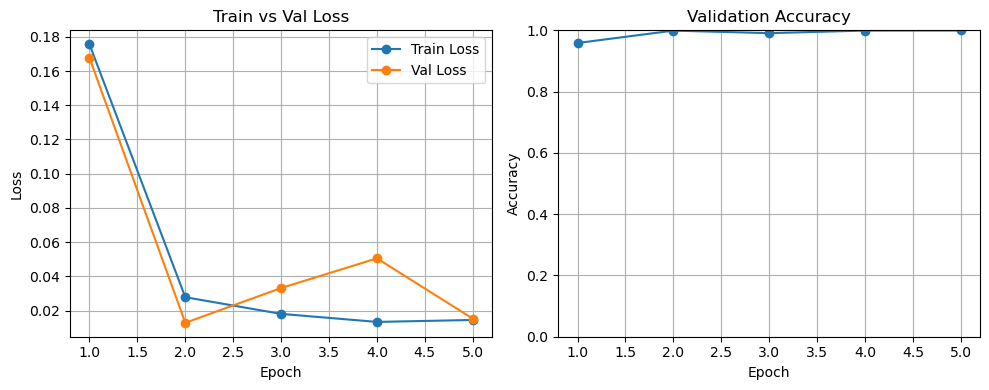

In [44]:
import matplotlib.pyplot as plt

epochs = range(1, 6)

plt.figure(figsize=(10,4))

# 1) Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Val Loss')
plt.legend()
plt.grid(True)

# 2) Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accs, marker='o', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.ylim(0, 1)
plt.grid(True)

plt.tight_layout()
plt.show()


# 6. 최적의 threshold 분석

In [43]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.linspace(0.0, 1.0, 1001) 

best_th = None
best_f1 = -1.0
best_prec = None
best_rec = None

for th in thresholds:
    y_pred = (y_probs_all >= th).astype(int)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_all,
        y_pred,
        average='binary',
        pos_label=1,
        zero_division=0
    )

    # precision, recall 둘 다 0.995 이상(f1을 중심으로 고려)
    if prec >= 0.995 and rec >= 0.995:
        if f1 > best_f1:
            best_f1 = f1
            best_th = th
            best_prec = prec
            best_rec = rec
            
            print(f"threshold={th} =>  prec={prec:.4f}, rec={rec:.4f}, f1={f1:.4f}")


print(f"Best threshold={best_th:.3f}, prec={best_prec:.4f}, rec={best_rec:.4f}, f1={best_f1:.4f}")


threshold=0.845 =>  prec=0.9950, rec=0.9983, f1=0.9967
threshold=0.847 =>  prec=0.9950, rec=0.9983, f1=0.9967
threshold=0.848 =>  prec=0.9951, rec=0.9983, f1=0.9967
threshold=0.849 =>  prec=0.9951, rec=0.9983, f1=0.9967
threshold=0.854 =>  prec=0.9952, rec=0.9983, f1=0.9967
threshold=0.857 =>  prec=0.9952, rec=0.9983, f1=0.9967
threshold=0.87 =>  prec=0.9953, rec=0.9982, f1=0.9968
threshold=0.873 =>  prec=0.9954, rec=0.9982, f1=0.9968
threshold=0.876 =>  prec=0.9954, rec=0.9982, f1=0.9968
threshold=0.881 =>  prec=0.9955, rec=0.9981, f1=0.9968
Best threshold=0.881, prec=0.9955, rec=0.9981, f1=0.9968


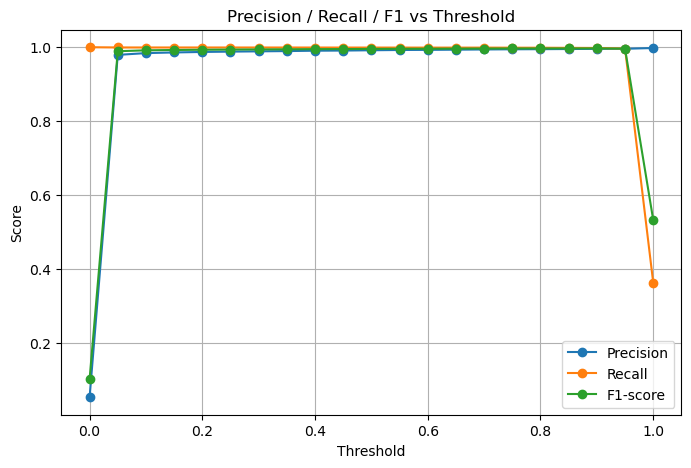

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# thresholds: 0.5 ~ 0.85, step 0.05
thresholds = np.arange(0.0, 1.01, 0.05)

prec_list = []
rec_list  = []
f1_list   = []

for th in thresholds:
    y_pred = (y_probs_all >= th).astype(int)  # 마지막 epoch의 y_probs_all 사용

    prec = precision_score(y_true_all, y_pred, zero_division=0)
    rec  = recall_score(y_true_all, y_pred, zero_division=0)
    f1   = f1_score(y_true_all,   y_pred, zero_division=0)

    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, prec_list, marker='o', label='Precision')
plt.plot(thresholds, rec_list,  marker='o', label='Recall')
plt.plot(thresholds, f1_list,   marker='o', label='F1-score')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.grid(True)
plt.legend()
plt.show()


In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold = 0.881
y_pred = (y_probs_all >= threshold).astype(int)

unique_attacks = np.unique(attack_all)

print(f"개별 공격 시나리오별 성능 지표")
for att in unique_attacks:
    
    y_true_att = (attack_all == att).astype(int) #공격별로 해당되는 세션 선별
    session_n = int(y_true_att.sum())  #해당 attack이 몇 개의 세션에서 나타났는지

    #공격 종류가 없는 경우 continue
    if session_n == 0:
        continue
    
    prec = precision_score(y_true_att, y_pred, zero_division=0)
    rec  = recall_score(y_true_att, y_pred, zero_division=0)
    f1   = f1_score(y_true_att,  y_pred,  zero_division=0)

    print(f"{str(att):15s} | session_n={session_n:3d} | "
          f"Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")


개별 공격 시나리오별 성능 지표
Analysis        | session_n=336 | Precision=0.0110  Recall=1.0000  F1=0.0217
BENIGN          | session_n=529627 | Precision=0.0045  Recall=0.0003  F1=0.0005
Backdoor        | session_n=1168 | Precision=0.0381  Recall=0.9991  F1=0.0734
DoS             | session_n=1552 | Precision=0.0503  Recall=0.9923  F1=0.0957
Exploits        | session_n=10555 | Precision=0.3436  Recall=0.9973  F1=0.5111
Fuzzers         | session_n=9220 | Precision=0.3008  Recall=0.9992  F1=0.4624
Generic         | session_n=1900 | Precision=0.0618  Recall=0.9963  F1=0.1164
Reconnaissance  | session_n=5064 | Precision=0.1653  Recall=0.9998  F1=0.2837
Shellcode       | session_n=708 | Precision=0.0231  Recall=1.0000  F1=0.0452
Worms           | session_n= 48 | Precision=0.0016  Recall=1.0000  F1=0.0031


# 7. 모델 저장

In [47]:
#학습된 모델 저장하기
torch.save(model.state_dict(),"tcn_model.pt")

In [48]:
import pickle
import numpy as np

with open("tcn_preprocess_cache.pkl", "wb") as f:
    pickle.dump({
        "data": data,
        "X_list": X_list,
        "y_arr": y_arr,
        "attack_list": attack_list,
        "feature_col": feature_col,
        "df_keys": filtered_keys,
    }, f)

# 8. 모델 불러오기

In [8]:
import torch
import torch.nn as nn
import numpy as np
from pytorch_tcn import TCN
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestRegressor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
with open("tcn_preprocess_cache.pkl", "rb") as f:
    cache = pickle.load(f)

data = cache["data"]
X_list = cache["X_list"]
y_arr = cache["y_arr"]
attack_list = cache["attack_list"]
feature_col = cache["feature_col"]
df_keys = cache["df_keys"]
y_probs_all = cache["y_probs_all"]
attack_all = cache["attack_all"]

In [3]:
class SessionTCN(nn.Module):
    def __init__(self, num_features, num_channels=[32, 64],
                 kernel_size=3, dropout=0.2):
        super().__init__()
        self.tcn = TCN(
            num_inputs=num_features,      # feature 개수
            num_channels=num_channels,    # 각 블록 채널 수
            kernel_size=kernel_size,
            dropout=dropout,
            causal=True,                 # 실시간 탐지를 해야하니까 → TRUE?
            input_shape='NCL',
            use_norm='weight_norm',
            activation='relu',
            use_skip_connections=True
        )
        # 최종 분류를 통한 출력(head)
        # TCN 출력: (N, C_last, L) → 시간축 평균 → Linear(1)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),      # (N, C, L) → (N, C, 1)
            nn.Flatten(),                 # (N, C, 1) → (N, C)
            nn.Linear(num_channels[-1], 1)
        )

    def forward(self, x):  # x: (N, F, L)
        h = self.tcn(x)          # (N, C_last, L)
        out = self.head(h)       # (N, 1)
        return out.squeeze(1)    # (N,)

In [5]:
#실제 모델 가져오기
F=X_list[0].shape[1]
model = SessionTCN(num_features=F).to(device) 
model.load_state_dict(torch.load("tcn_model.pt"))
model.eval()

SessionTCN(
  (tcn): TCN(
    (downsample_skip_connection): ModuleList(
      (0): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
      (1): None
    )
    (activation_skip_out): ReLU()
    (network): ModuleList(
      (0): TemporalBlock(
        (conv1): ParametrizedTemporalConv1d(
          46, 32, kernel_size=(3,), stride=(1,)
          (padder): TemporalPad1d(
            (pad): ConstantPad1d(padding=(2, 0), value=0.0)
          )
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
        (conv2): ParametrizedTemporalConv1d(
          32, 32, kernel_size=(3,), stride=(1,)
          (padder): TemporalPad1d(
            (pad): ConstantPad1d(padding=(2, 0), value=0.0)
          )
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
        (activation1): ReLU()
        (activation2): R

# 9. 공격 유형별 탐지율(bar, scatter plot)

In [28]:
plt.rcParams['font.family'] = 'Malgun Gothic'   # 폰트 지정
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지

### 9-1. Bar graph

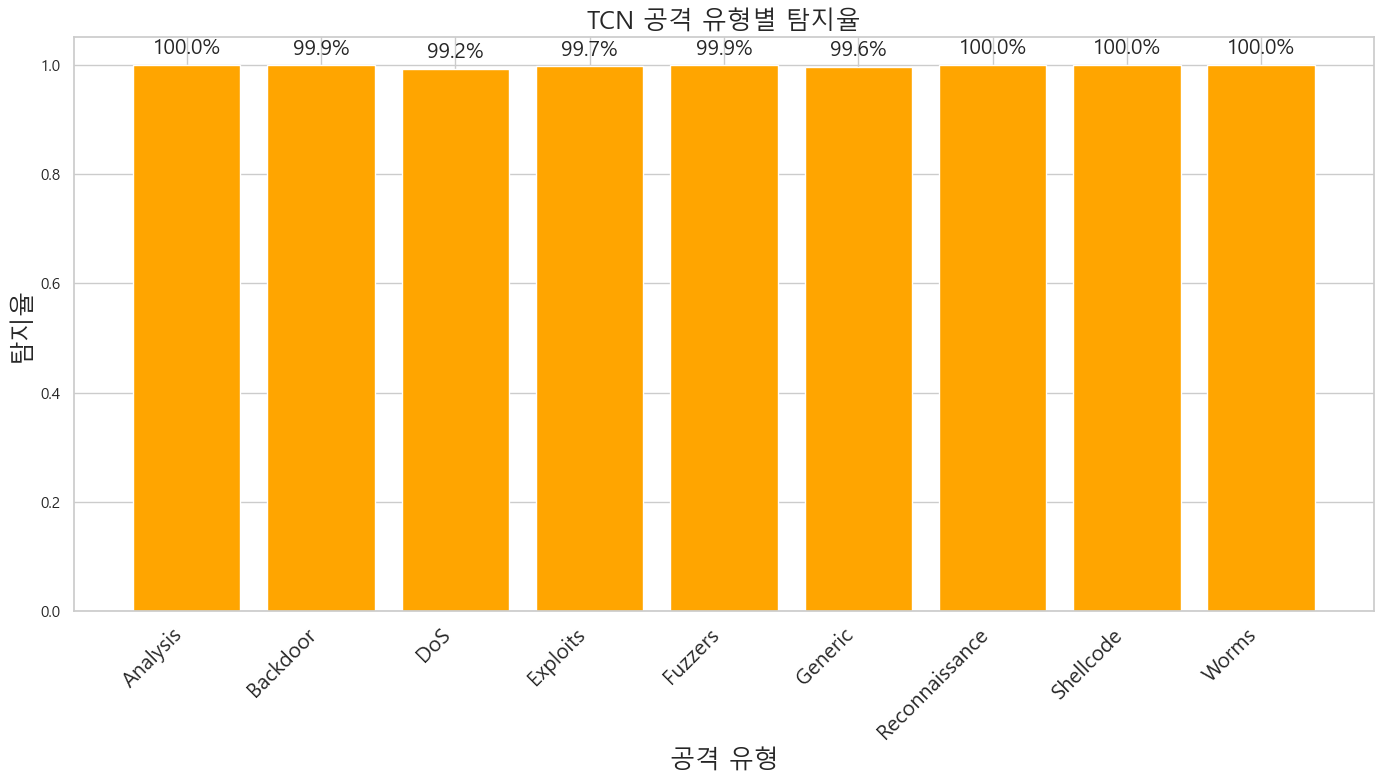

In [33]:
threshold = 0.881
y_pred = (y_probs_all >= threshold).astype(int)

unique_attacks = np.unique(attack_all)

attack_names = []
detect_rates = []

#정상은 제외
for att in unique_attacks:
    if att == "BENIGN":
        continue
    
    y_true_att = (attack_all == att).astype(int)
    session_n = int(y_true_att.sum())
    if session_n == 0:
        continue

    rec = recall_score(y_true_att, y_pred, zero_division=0)
    attack_names.append(att)
    detect_rates.append(rec)

    
#그래프
fig, ax = plt.subplots(figsize=(14, 8))   
bars = ax.bar(attack_names, detect_rates, color="orange")

ax.set_ylim(0, 1.05)
ax.set_xlabel("공격 유형", fontsize=18)
ax.set_ylabel("탐지율", fontsize=18)
ax.set_title(f"TCN 공격 유형별 탐지율", fontsize=18)

# 막대 위에 100.0% 라벨 출력
for bar, rate in zip(bars, detect_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{rate*100:.1f}%",
            ha="center", va="bottom", fontsize=15)

plt.xticks(rotation=45, ha="right",fontsize=15)
plt.tight_layout()
plt.show()


### 9-2. Scatter plot

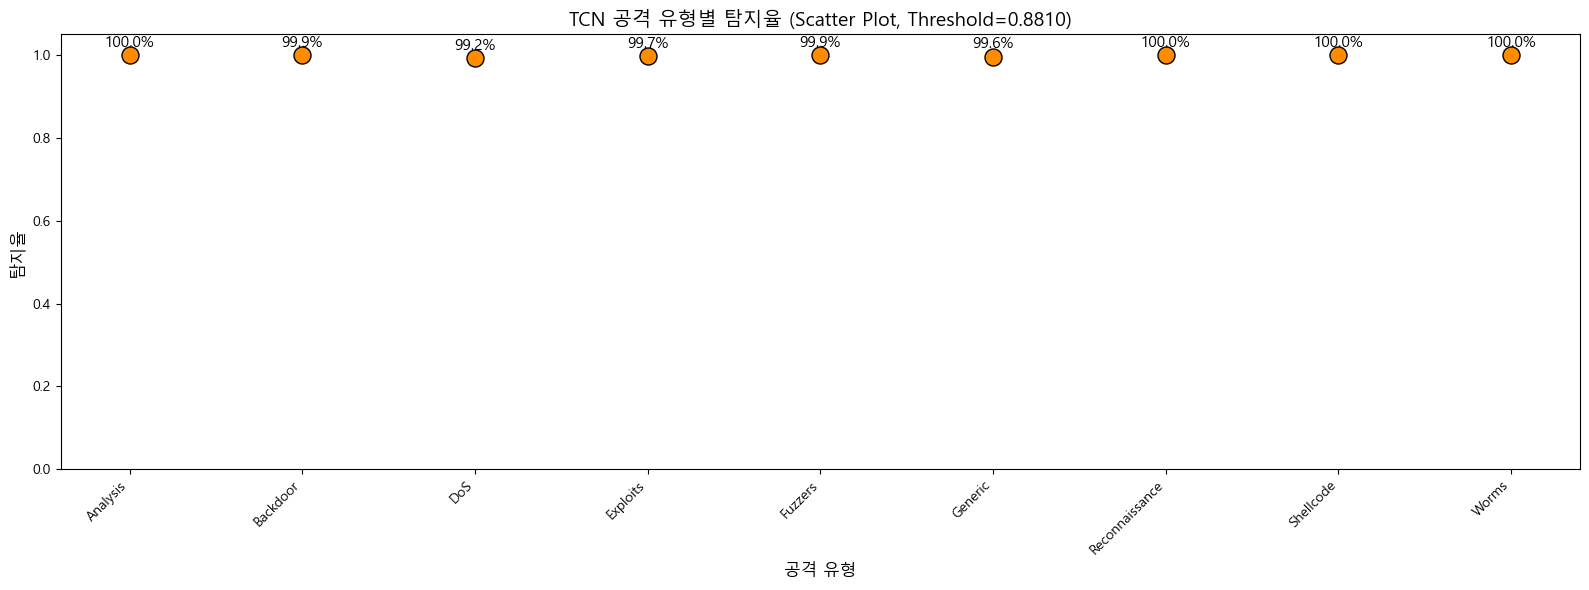

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# attack_names  : 공격 유형 리스트
# detect_rates  : 각 공격 유형별 recall 값 (0~1)

fig, ax = plt.subplots(figsize=(16, 6))

# 산점도
ax.scatter(attack_names, detect_rates,
           color="darkorange", s=150, edgecolor="black")

# y축 범위
ax.set_ylim(0, 1.05)

# 라벨 & 제목
ax.set_xlabel("공격 유형", fontsize=12)
ax.set_ylabel("탐지율", fontsize=12)
ax.set_title(f"TCN 공격 유형별 탐지율 (Scatter Plot, Threshold={threshold:.4f})",
             fontsize=14)

# 점 위에 값 표시
for x, rate in zip(attack_names, detect_rates):
    ax.text(x, rate+0.01, f"{rate*100:.1f}%",
            ha="center", va="bottom", fontsize=11)

# x축 라벨 기울이기
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


# 10. XAI / SHAP

In [16]:
# TCN XAI & Feature 분석 파이프라인

sns.set(style="whitegrid")
max_len=50

### 10-1. 세션 단위 요약 feature DataFrame 만들기

In [17]:
def build_session_summary_df(
    df_keys,
    X_list,
    y_arr,
    attack_list,
    feature_col,
    data=None,
):
    
    rows = []

    for i, key in enumerate(df_keys):
        X_seq = X_list[i]          # (L_i, F)
        y = int(y_arr[i])
        attack = attack_list[i]

        # 세션 요약: 각 feature의 평균값 (원하면 max, std 등 추가 가능)
        feat_mean = X_seq.mean(axis=0)

        row = {
            "session_idx": i,
            "Label": y,
            "Attack": attack,
        }

        # 세션 key를 사람이 보기 좋게 문자열로 저장
        row["session_key"] = str(key)

        # 원하면 src/dst 포트 같은 것도 붙일 수 있음 (첫 flow 기준)
        if data is not None:
            # key는 (IPV4_SRC_ADDR, L4_SRC_PORT, IPV4_DST_ADDR, L4_DST_PORT, PROTOCOL)
            row["IPV4_SRC_ADDR"] = key[0]
            row["L4_SRC_PORT"]   = key[1]
            row["IPV4_DST_ADDR"] = key[2]
            row["L4_DST_PORT"]   = key[3]
            row["PROTOCOL"]      = key[4]

        # feature 평균값 추가
        for f_name, val in zip(feature_col, feat_mean):
            row[f_name] = float(val)

        rows.append(row)

    session_df = pd.DataFrame(rows)
    return session_df

In [18]:
# (1) 세션 요약 DataFrame 구성
session_df = build_session_summary_df(
    df_keys=df_keys,
    X_list=X_list,
    y_arr=y_arr,
    attack_list=attack_list,
    feature_col=feature_col,
    data=data,   
)

### 10-2. TCN 모델로 각 세션의 attack score 계산

In [19]:
def compute_tcn_attack_scores(model, device, X_list, max_len):

    model.eval()
    F = X_list[0].shape[1]
    scores = []

    with torch.no_grad():
        for X_seq in X_list:
            L = X_seq.shape[0]
            if L > max_len:
                X_seq = X_seq[:max_len, :]
                L = max_len

            # (F, max_len) 패딩 (train 때 collate_fn과 동일 방식)
            padded = np.zeros((F, max_len), dtype=np.float32)
            padded[:, :L] = X_seq.T  # (L, F) → (F, L)

            x_tensor = torch.tensor(
                padded[None, :, :],  # (1, F, max_len)
                dtype=torch.float32,
                device=device,
            )

            logits = model(x_tensor)         
            prob_attack = torch.sigmoid(logits).item()
            scores.append(prob_attack)

    return np.array(scores, dtype=np.float32)

In [20]:
# (2) TCN Attack Score 계산
tcn_scores = compute_tcn_attack_scores(
    model=model,
    device=device,
    X_list=X_list,
    max_len=max_len,
)
session_df["tcn_attack_score"] = tcn_scores

print("[INFO] TCN attack score 계산 완료.")

[INFO] TCN attack score 계산 완료.


### 10-3. Benign vs Attack 주요 feature 분포 시각화

In [21]:
def plot_benign_vs_attack_features(session_df, feature_col, top_k=5):
    """
    mutual_info 기반으로 Label(0/1)과 가장 연관이 큰 상위 top_k feature를 골라서
    Benign vs Attack 분포(KDE) 시각화.
    """
    X = session_df[feature_col].values
    y = session_df["Label"].values

    mi = mutual_info_classif(X, y, random_state=42)
    top_idx = np.argsort(mi)[-top_k:][::-1]
    top_features = [feature_col[i] for i in top_idx]

    session_df["Label_str"] = np.where(session_df["Label"] == 0, "Benign", "Attack")

    print(f"[INFO] Benign vs Attack 분포를 그릴 상위 feature: {top_features}")

    for feat in top_features:
        plt.figure(figsize=(6, 4))
        sns.kdeplot(
            data=session_df,
            x=feat,
            hue="Label_str",
            common_norm=False,
            fill=True,
            alpha=0.4,
        )
        plt.title(f"[TCN] Benign vs Attack - {feat} 분포")
        plt.tight_layout()
        plt.show()

[INFO] Benign vs Attack 분포를 그릴 상위 feature: ['MIN_TTL', 'MIN_IP_PKT_LEN', 'SHORTEST_FLOW_PKT', 'MAX_TTL', 'SERVER_TCP_FLAGS']


C:\Users\USER\AppData\Local\Temp\ipykernel_21064\4230608677.py:28: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_21064\4230608677.py:28: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


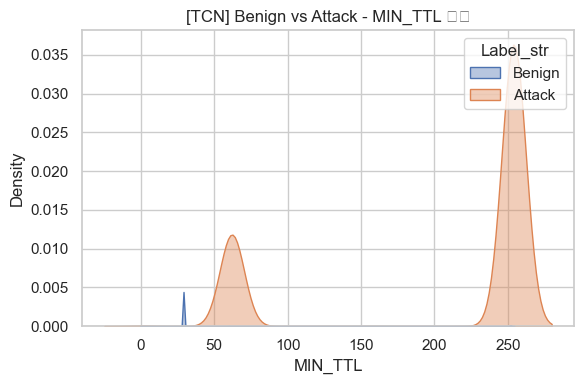

C:\Users\USER\AppData\Local\Temp\ipykernel_21064\4230608677.py:28: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_21064\4230608677.py:28: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


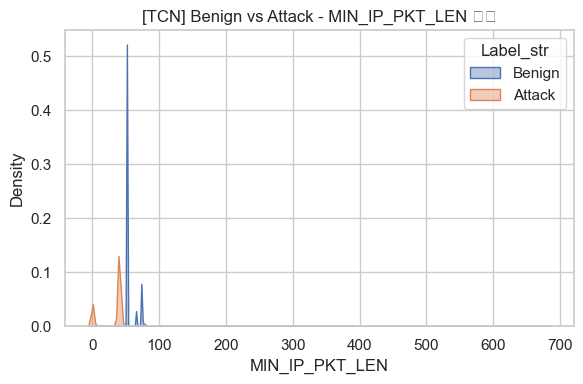

C:\Users\USER\AppData\Local\Temp\ipykernel_21064\4230608677.py:28: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_21064\4230608677.py:28: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


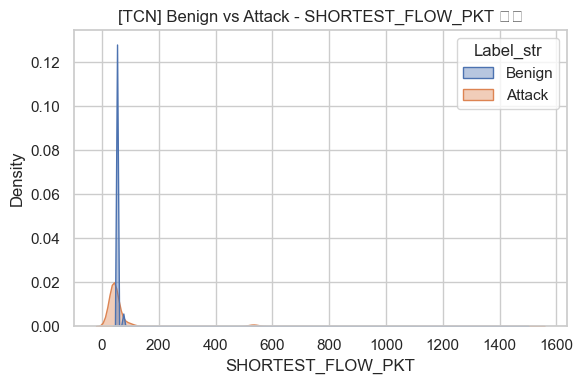

C:\Users\USER\AppData\Local\Temp\ipykernel_21064\4230608677.py:28: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_21064\4230608677.py:28: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


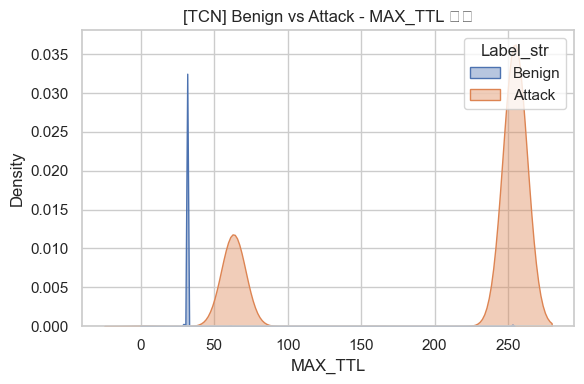

C:\Users\USER\AppData\Local\Temp\ipykernel_21064\4230608677.py:28: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_21064\4230608677.py:28: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


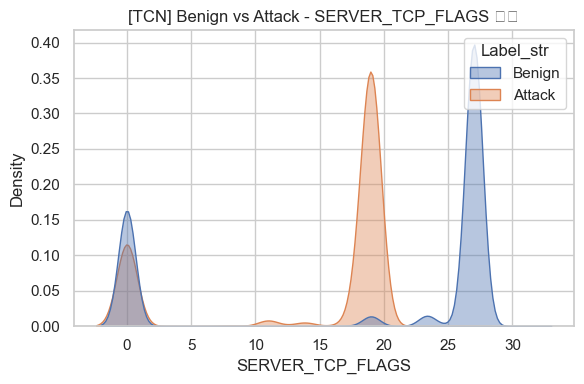

In [22]:
# (3) Benign vs Attack 주요 feature 분포 (상위 5개 feature)
plot_benign_vs_attack_features(
    session_df=session_df,
    feature_col=feature_col,
    top_k=5,
)

### 10-4. 공격 유형별 score 분포 및 high-score 세션 예시

In [23]:
def plot_attack_type_score_dist_and_examples(session_df, score_col="tcn_attack_score", top_n=5):
    """
    - 공격 유형별 TCN score 분포(KDE)
    - 각 공격 유형에서 score 상위 top_n 세션 출력
    """
    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    for atk, sub in session_df.groupby("Attack"):
        sns.kdeplot(
            x=sub[score_col],
            fill=True,
            alpha=0.4,
            common_norm=False,
            ax=ax,
            label=atk,     
        )

    ax.set_title("[TCN] 공격 유형별 감지 점수 분포")
    ax.set_xlabel(score_col)
    ax.set_ylabel("Density")
    ax.legend(title="Attack", loc="upper left")

    plt.tight_layout()
    plt.show()

    #공격 유형별로 score 높은 세션 5개씩 출력
    attack_types = session_df["Attack"].unique()
    for atk in attack_types:
        sub = session_df[session_df["Attack"] == atk].nlargest(top_n, score_col)

        print(f"\n=== [TCN] Attack Type: {atk} | Top-{top_n} High-Score Sessions ===")
        cols_to_show = ["session_idx", "session_key", "Label", "Attack", score_col]
        for c in ["IPV4_SRC_ADDR", "L4_SRC_PORT", "IPV4_DST_ADDR", "L4_DST_PORT", "PROTOCOL"]:
            if c in sub.columns:
                cols_to_show.append(c)

        print(sub[cols_to_show].head(top_n).to_string(index=False))

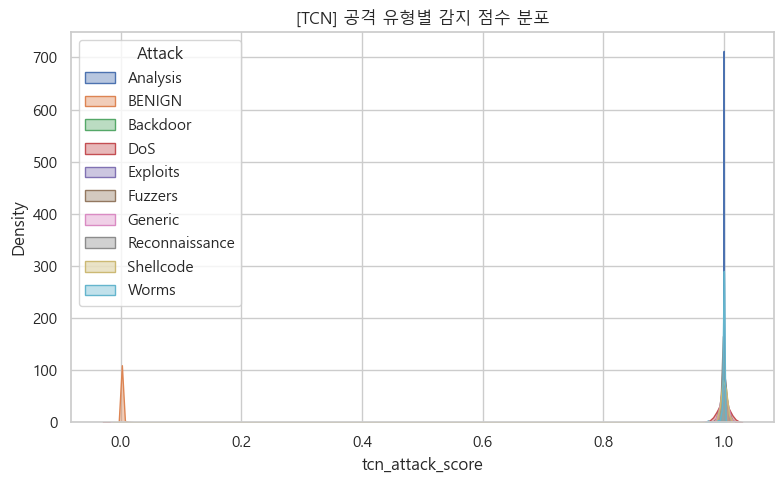


=== [TCN] Attack Type: BENIGN | Top-5 High-Score Sessions ===
 session_idx                                       session_key  Label Attack  tcn_attack_score  IPV4_SRC_ADDR  L4_SRC_PORT IPV4_DST_ADDR  L4_DST_PORT  PROTOCOL
         585     ('149.171.126.1', 80, '59.166.0.5', 60659, 6)      0 BENIGN               1.0  149.171.126.1           80    59.166.0.5        60659         6
         825  ('149.171.126.10', 25, '175.45.176.1', 12113, 6)      0 BENIGN               1.0 149.171.126.10           25  175.45.176.1        12113         6
         826  ('149.171.126.10', 25, '175.45.176.2', 27072, 6)      0 BENIGN               1.0 149.171.126.10           25  175.45.176.2        27072         6
         828    ('149.171.126.10', 53, '175.45.176.3', 53, 17)      0 BENIGN               1.0 149.171.126.10           53  175.45.176.3           53        17
         832 ('149.171.126.10', 143, '175.45.176.1', 35912, 6)      0 BENIGN               1.0 149.171.126.10          143  175.45.176.1 

In [34]:
# (4) 공격 유형별 score 분포 + high-score 세션 예시
plot_attack_type_score_dist_and_examples(
    session_df=session_df,
    score_col="tcn_attack_score",
    top_n=5,
)

### 10-5. Surrogate 모델 + SHAP으로 feature 중요도 분석

In [25]:
def run_tcn_shap_with_surrogate(session_df, feature_col, score_col="tcn_attack_score",
                                n_estimators=100, max_depth=5,
                                n_sample=300):
    """
    TCN은 시퀀스를 사용하기 때문에,
    1.세션 요약 feature(평균값) -> 2.TCN score 를 학습하는 surrogate 모델(RandomForestRegressor) -> 3.SHAP 적용 순으로 XAI 수행.

    - global: summary_plot
    - local: score가 가장 높은 세션 1개에 대한 force_plot
    """
    X = session_df[feature_col].values
    y_score = session_df[score_col].values

    # surrogate 모델 학습
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X, y_score)
    print("[INFO] TCN surrogate RandomForestRegressor 학습 완료.")

    # 샘플링 (너무 크면 SHAP 느려지니까 n_sample만 사용)
    n = X.shape[0]
    n_sample = min(n_sample, n)
    idx_sample = np.random.choice(n, size=n_sample, replace=False)
    X_sample = X[idx_sample]

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_sample)

    print("[INFO] SHAP summary_plot (global feature importance) 생성 중...")
    shap.summary_plot(
        shap_values,
        X_sample,
        feature_names=feature_col,
        show=True
    )

    # score가 가장 높은 세션 1개에 대한 local 설명
    idx_top = session_df[score_col].idxmax()
    x_single = session_df.loc[idx_top, feature_col].values

    shap_single = explainer.shap_values(x_single.reshape(1, -1))

    print(f"[INFO] score가 가장 높은 세션 (index={idx_top})에 대한 local SHAP force_plot 생성 중...")
    shap.force_plot(
        explainer.expected_value,
        shap_single[0],
        x_single,
        feature_names=feature_col,
        matplotlib=True
    )
    plt.show()

[INFO] TCN surrogate RandomForestRegressor 학습 완료.
[INFO] SHAP summary_plot (global feature importance) 생성 중...


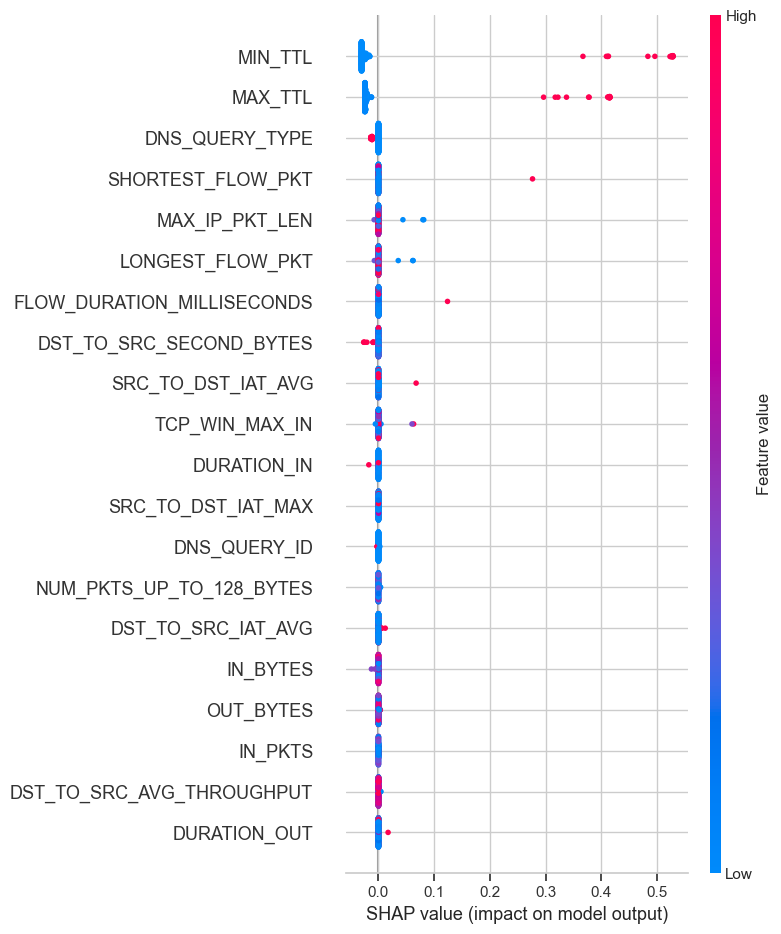

[INFO] score가 가장 높은 세션 (index=585)에 대한 local SHAP force_plot 생성 중...


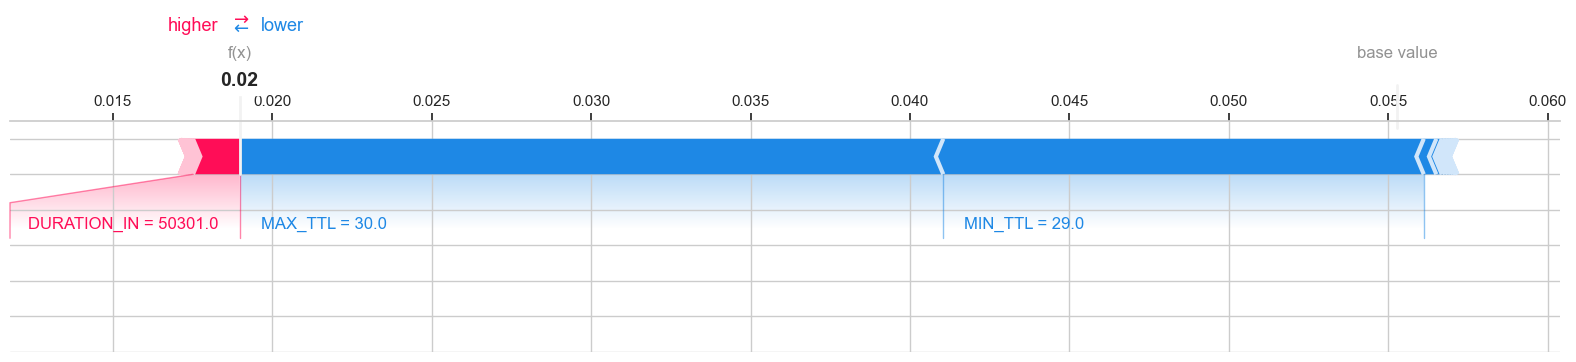


[DONE] TCN XAI / Feature 분석 파이프라인 완료.


In [26]:
# (5) Surrogate + SHAP 기반 feature 중요도 분석
run_tcn_shap_with_surrogate(
    session_df=session_df,
    feature_col=feature_col,
    score_col="tcn_attack_score",
    n_estimators=100,
    max_depth=5,
    n_sample=300,
)

print("\n[DONE] TCN XAI / Feature 분석 파이프라인 완료.")